In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2

In [3]:
df = pd.read_csv("credit_dataset_5000_enhanced_final.csv")

In [4]:
print(df.head())

   Age  Income  Coapplicant_Income  Dependents  Employ_Status   Debt  \
0   61   26587               10296           1       Employed  56824   
1   36   23236               13264           3  Self-employed  78620   
2   66   19245               32648           5       Employed  34596   
3   29   64148               19563           1       Employed  59612   
4   43  101424               49221           1     Unemployed   1523   

   PrevLDefault  CIBIL_Score  Loan_Approval  
0             1          465              0  
1             1          456              1  
2             0          572              0  
3             0          620              0  
4             0          659              0  


In [5]:
df['Employ_Status'].unique()

array(['Employed', 'Self-employed', 'Unemployed'], dtype=object)

In [6]:
df.isnull().sum()

,0
Age,0
Income,0
Coapplicant_Income,0
Dependents,0
Employ_Status,0
Debt,0
PrevLDefault,0
CIBIL_Score,0
Loan_Approval,0


In [7]:
df['PrevLDefault'].unique()

array([1, 0])

In [8]:
(df['Loan_Approval'] == 0).sum()

np.int64(2504)

In [9]:
(df['Loan_Approval'] == 1).sum()

np.int64(2496)

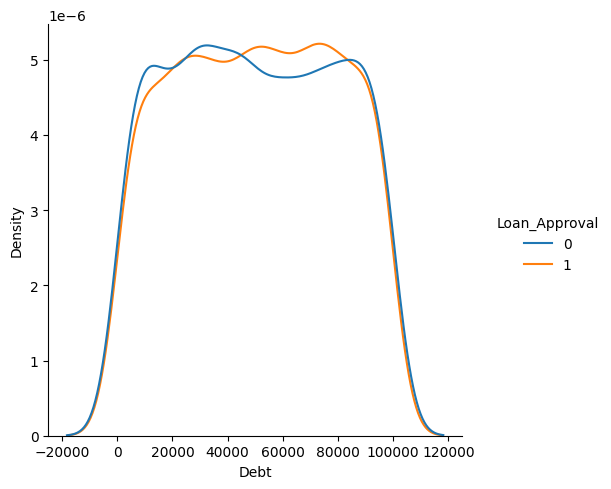

In [10]:
sns.displot(
    data=df,
    x="Debt",
    hue="Loan_Approval",
    kind="kde"
)

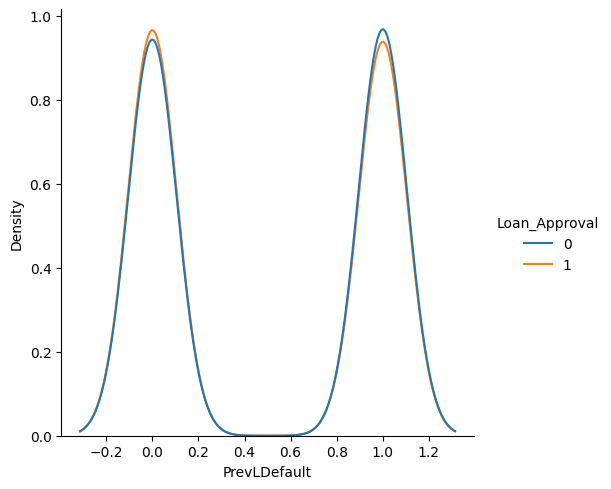

In [11]:
sns.displot(
    data=df,
    x="PrevLDefault",
    hue="Loan_Approval",
    kind="kde"
)

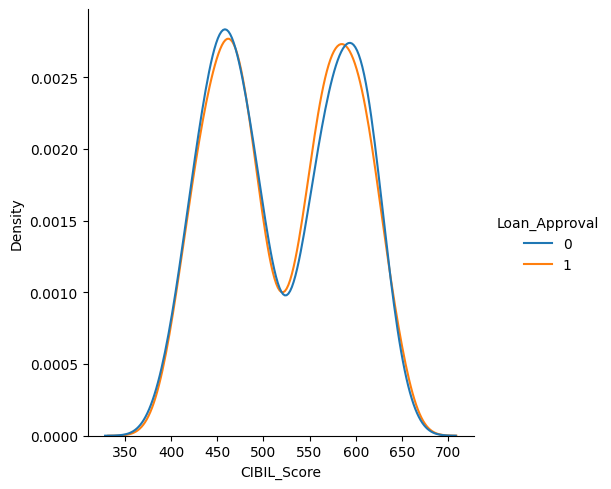

In [12]:
sns.displot(
    data=df,
    x="CIBIL_Score",
    hue="Loan_Approval",
    kind="kde"
)


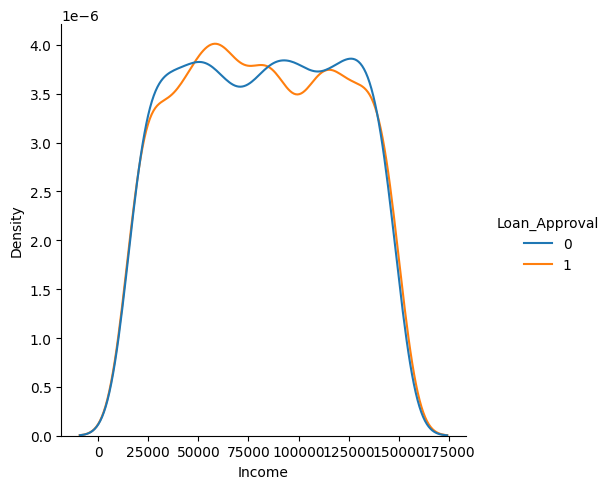

In [13]:
sns.displot(
    data=df,
    x="Income",
    hue="Loan_Approval",
    kind="kde"
)

<Axes: xlabel='Loan_Approval', ylabel='CIBIL_Score'>

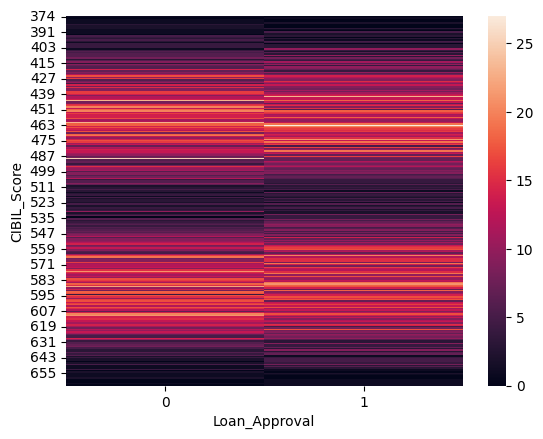

In [14]:
sns.heatmap(pd.crosstab(df['CIBIL_Score'],df['Loan_Approval']))

In [15]:
pd.crosstab(df['PrevLDefault'], df['Loan_Approval'])

Loan_Approval,0,1
PrevLDefault,,
0,1236,1266
1,1268,1230


In [16]:
df

,Age,Income,Coapplicant_Income,Dependents,Employ_Status,Debt,PrevLDefault,CIBIL_Score,Loan_Approval
0,61,26587,10296,1,Employed,56824,1,465,0
1,36,23236,13264,3,Self-employed,78620,1,456,1
2,66,19245,32648,5,Employed,34596,0,572,0
3,29,64148,19563,1,Employed,59612,0,620,0
4,43,101424,49221,1,Unemployed,1523,0,659,0
...,...,...,...,...,...,...,...,...,...
4995,33,76196,76786,3,Self-employed,80218,1,445,0
4996,32,93373,5342,0,Self-employed,78488,1,471,1
4997,57,21445,25752,4,Unemployed,27510,1,481,0
4998,58,34367,47047,3,Unemployed,2577,1,476,1


In [18]:
score = (
    (df['CIBIL_Score'] - df['CIBIL_Score'].mean()) / df['CIBIL_Score'].std() * 2.5
    - df['PrevLDefault'] * 2.0         # removed - it's ~-0.91 correlated with CIBIL_Score already
    - (df['Debt'] / df['Income'].replace(0, np.nan).fillna(df['Income'].mean())) * 1.5
    + (df['Income'] - df['Income'].mean()) / df['Income'].std() * 1.0
    - df['Dependents'] * 0.15
    + np.where(df['Employ_Status'] == 'Employed', 0.5,
        np.where(df['Employ_Status'] == 'Self-employed', 0.2, -0.8))
)


In [19]:
threshold = score.median()
df['Loan_Approval'] = (score > threshold).astype(int)

print(df['Loan_Approval'].value_counts(normalize=True))

Loan_Approval
0    0.5
1    0.5
Name: proportion, dtype: float64


In [20]:
# Cell 1: Train-Test Split (with stratification)
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Loan_Approval"])
y = df["Loan_Approval"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
# Cell 2: Preprocessing Pipeline & Model Training
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Identify column types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

# Preprocessing for numerical and categorical features
num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [("num", num_pipeline, num_cols), ("cat", cat_pipeline, cat_cols)]
)

# Full Pipeline with Logistic Regression
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000, random_state=42, class_weight="balanced"
            ),
        ),
    ]
)

# Fit the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Income', 'Coapplicant_Income', 'Dependents', 'Debt',
       'PrevLDefault', 'CIBIL_Score'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Employ_Status'], dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [23]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [24]:
trf1 = ColumnTransformer([
    ('employ_status',
     OrdinalEncoder(categories=[['Unemployed', 'Employed', 'Self-employed']],
                     handle_unknown='use_encoded_value',
                     unknown_value=-1),
     [4])
], remainder='passthrough')

result = trf1.fit_transform(X_train)
result1=trf1.fit_transform(X_test)
Employment_train = pd.DataFrame(result, columns=trf1.get_feature_names_out())
Employment_test = pd.DataFrame(result1,columns=trf1.get_feature_names_out())
print(Employment_train)

      employ_status__Employ_Status  remainder__Age  remainder__Income  \
0                              0.0            57.0           112595.0   
1                              2.0            60.0           119341.0   
2                              1.0            78.0            98894.0   
3                              2.0            61.0            88335.0   
4                              1.0            49.0            40350.0   
...                            ...             ...                ...   
3995                           2.0            51.0            62026.0   
3996                           2.0            53.0            95646.0   
3997                           0.0            61.0            61737.0   
3998                           1.0            33.0            63264.0   
3999                           1.0            23.0           110000.0   

      remainder__Coapplicant_Income  remainder__Dependents  remainder__Debt  \
0                           60378.0         

In [25]:
Employment_train.columns = [col.replace("remainder__", "").replace("employ_status__", "")
                            for col in Employment_train.columns]
Employment_test.columns = [col.replace("remainder__", "").replace("employ_status__", "")
                           for col in Employment_test.columns]

In [26]:
Employment_train

,Employ_Status,Age,Income,Coapplicant_Income,Dependents,Debt,PrevLDefault,CIBIL_Score
0,0.0,57.0,112595.0,60378.0,2.0,5513.0,0.0,633.0
1,2.0,60.0,119341.0,31639.0,4.0,10215.0,0.0,575.0
2,1.0,78.0,98894.0,80514.0,3.0,87347.0,0.0,606.0
3,2.0,61.0,88335.0,45205.0,3.0,10751.0,1.0,495.0
4,1.0,49.0,40350.0,10534.0,1.0,39427.0,1.0,444.0
...,...,...,...,...,...,...,...,...
3995,2.0,51.0,62026.0,68306.0,1.0,84030.0,1.0,474.0
3996,2.0,53.0,95646.0,83910.0,1.0,73179.0,0.0,631.0
3997,0.0,61.0,61737.0,72894.0,5.0,69142.0,0.0,556.0
3998,1.0,33.0,63264.0,65478.0,5.0,47794.0,1.0,461.0


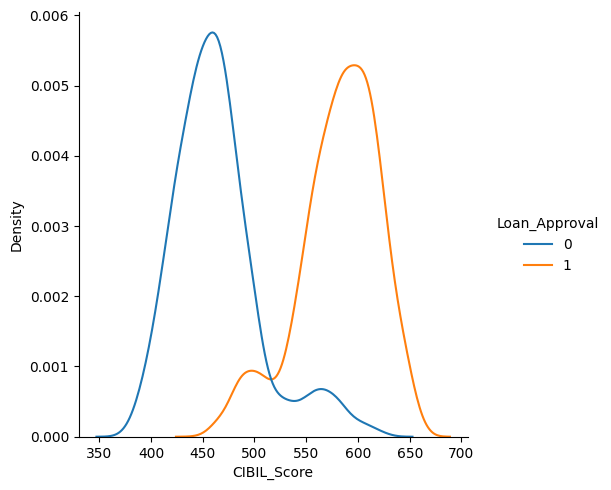

In [27]:
sns.displot(
    data=df,
    x="CIBIL_Score",
    hue="Loan_Approval",
    kind="kde"
)

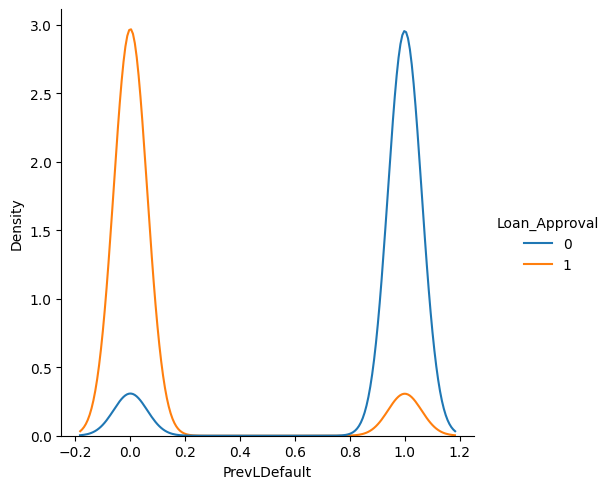

In [28]:
sns.displot(
    data=df,
    x="PrevLDefault",
    hue="Loan_Approval",
    kind="kde"
)

In [38]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Inverse of regularization strength
    'solver': ['liblinear', 'lbfgs'] # Solvers that support L2 regularization and small datasets
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=5000), # Increased max_iter for convergence
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1 # Use all available CPU cores
)

# Fit GridSearchCV to the training data
grid_search.fit(Employment_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Get the best model
best_logreg_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned = best_logreg_model.predict(Employment_test)
print(f"Test Accuracy with Tuned Model: {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report for Tuned Model:\n")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'C': 100, 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.9617
Test Accuracy with Tuned Model: 0.9580

Classification Report for Tuned Model:

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       500
           1       0.95      0.96      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



In [36]:
importances = pd.Series(
    best_logreg_model.coef_[0],
    index=Employment_train.columns
).sort_values(ascending=False)

print(importances)

Employ_Status         1.212304e+00
CIBIL_Score           8.901757e-02
Age                   8.767761e-03
Income                1.425281e-04
Coapplicant_Income    3.781305e-07
Debt                 -6.767331e-05
Dependents           -3.551397e-01
PrevLDefault         -8.006168e+00
dtype: float64


### Confusion Matrix

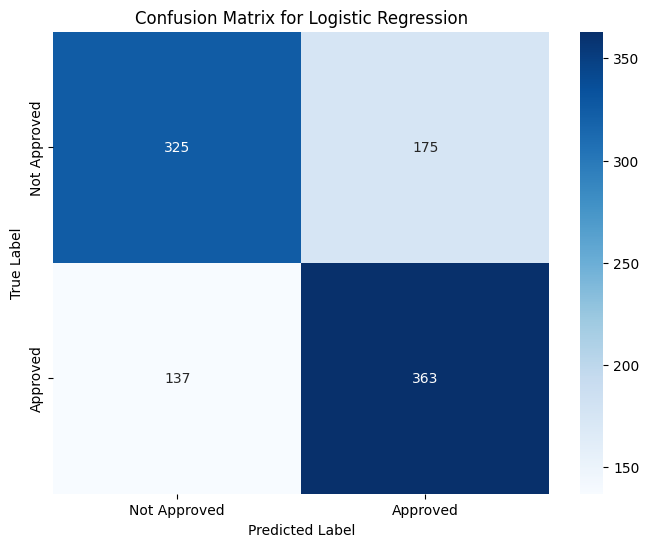

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### ROC Curve

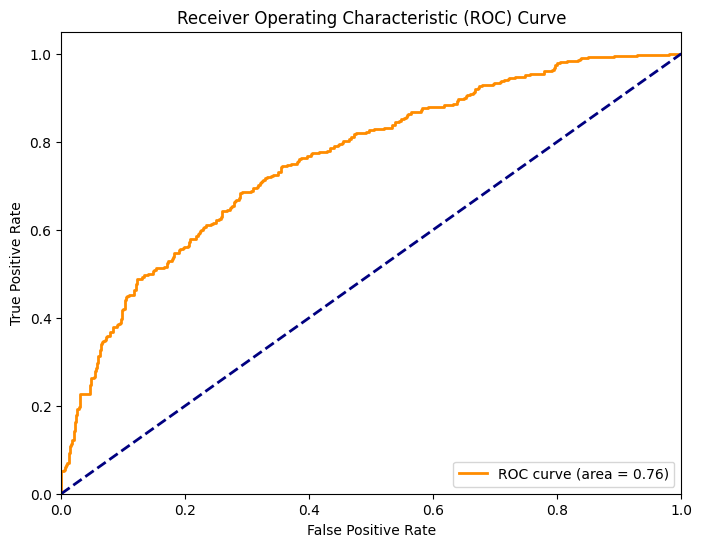

In [ ]:
y_pred_proba = logreg_model.predict_proba(Employment_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()